In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.impute as kNNImputer
from sklearn.preprocessing import MinMaxScaler

oilData = pd.read_csv("oil_presence_trainset.csv")

In [2]:
oilData.head(10)

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Limestone,17.667992,834.277472,NaN,0.705933,2.431355,2228.0,1
1,Limestone,27.665758,578.158034,NaN,0.545806,2.606158,1610.0,0
2,Sandstone,28.855946,404.790685,NaN,0.167530,1.143136,2344.0,0
3,Sandstone,0.410957,887.836673,Dome,0.026852,2.673532,NaN,0
4,Shale,16.490538,562.288802,NaN,NaN,2.064440,NaN,0
5,Shale,16.654792,979.154784,Anticline,0.044457,4.927771,3556.0,1
6,Limestone,8.342985,NaN,Fault,NaN,0.439339,NaN,0
7,Shale,13.111546,263.806644,Fault,0.375041,4.602919,NaN,0
8,Shale,NaN,NaN,Fault,NaN,0.672804,867.0,0
9,Sandstone,28.419000,728.106328,Anticline,0.194321,4.097616,NaN,0


In [3]:
oilData.describe()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
count,2197.000000,1814.000000,1950.000000,2057.000000,1732.000000,3000.000000
mean,14.762194,505.594049,0.490680,2.545868,2764.426674,0.277667
std,8.750759,281.718143,0.286654,1.470783,1288.782908,0.447923
min,0.018825,1.185010,0.000333,0.001007,500.000000,0.000000
25%,7.152815,273.913289,0.245138,1.286000,1650.500000,0.000000
50%,14.602531,504.565289,0.485856,2.550525,2772.500000,0.000000
75%,22.417084,751.803683,0.729728,3.842006,3820.000000,1.000000
max,29.992547,997.134762,0.999353,4.998872,4997.000000,1.000000


In [4]:
oilData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rock_Type                  3000 non-null   object 
 1   Porosity                   2197 non-null   float64
 2   Permeability               1814 non-null   float64
 3   Trap_Type                  2233 non-null   object 
 4   Seismic_Score              1950 non-null   float64
 5   Proximity_to_Oil_Field     2057 non-null   float64
 6   Estimated_Reservoir_Depth  1732 non-null   float64
 7   Oil_Presence               3000 non-null   int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 187.6+ KB


In [5]:
cp_row = oilData.dropna() #drop any row with missing data
#cp_row

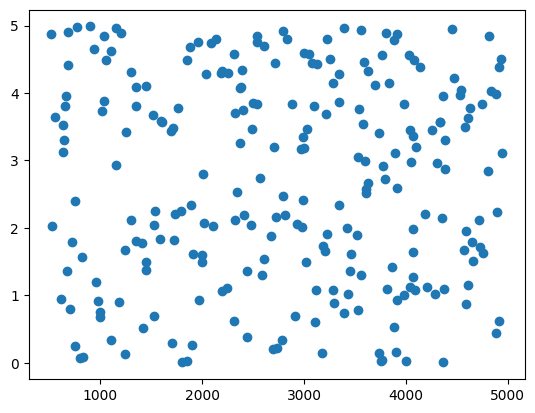

In [6]:
x = cp_row.Estimated_Reservoir_Depth
y = cp_row.Proximity_to_Oil_Field

plt.scatter(x, y)
plt.show()

In [7]:
cp_row.describe()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,15.426316,499.284687,0.485876,2.682992,2808.475207,0.264463
std,8.919082,291.527837,0.284503,1.510118,1270.591597,0.441961
min,0.048036,18.134529,0.006394,0.003744,517.000000,0.000000
25%,7.207491,256.740694,0.249579,1.382075,1741.500000,0.000000
50%,16.649783,462.358664,0.446967,2.770711,2922.000000,0.000000
75%,23.301967,751.218879,0.713240,4.021814,3885.500000,1.000000
max,29.949563,997.134762,0.997357,4.987292,4945.000000,1.000000


In [8]:
oilData.isna()

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,False,False,False,True,False,False,False,False
1,False,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,True,False
4,False,False,False,True,True,False,True,False
...,...,...,...,...,...,...,...,...
2995,False,False,False,False,False,True,False,False
2996,False,True,True,False,False,True,False,False
2997,False,False,False,False,False,True,False,False
2998,False,False,False,False,False,False,True,False


In [9]:
from sklearn import impute
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

df = oilData.drop(columns=['Oil_Presence'])
y = oilData['Oil_Presence']
#import sklearn.impute as kNNImputer


In [10]:
oilData

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Limestone,17.667992,834.277472,NaN,0.705933,2.431355,2228.0,1
1,Limestone,27.665758,578.158034,NaN,0.545806,2.606158,1610.0,0
2,Sandstone,28.855946,404.790685,NaN,0.167530,1.143136,2344.0,0
3,Sandstone,0.410957,887.836673,Dome,0.026852,2.673532,NaN,0
4,Shale,16.490538,562.288802,NaN,NaN,2.064440,NaN,0
...,...,...,...,...,...,...,...,...
2995,Shale,5.103463,817.140730,Fault,0.150019,NaN,2680.0,0
2996,Sandstone,NaN,NaN,Fault,0.956612,NaN,2161.0,1
2997,Shale,1.244975,913.597456,Anticline,0.148689,NaN,3800.0,1
2998,Limestone,17.306498,287.616645,Anticline,0.951127,3.328581,NaN,0


In [11]:
print(f"Missing values in Permeability BEFORE: {df['Permeability'].isnull().sum()}")
print(f"Missing values in Porosity BEFORE: {df['Porosity'].isnull().sum()}")
print(f"Missing values in Seismic_Score BEFORE: {df['Seismic_Score'].isnull().sum()}")
print(f"Missing values in Proximity_to_Oil_Field BEFORE: {df['Proximity_to_Oil_Field'].isnull().sum()}")
print(f"Missing values in Estimated_Reservoir_Depth BEFORE: {df['Estimated_Reservoir_Depth'].isnull().sum()}")

Missing values in Permeability BEFORE: 1186
Missing values in Porosity BEFORE: 803
Missing values in Seismic_Score BEFORE: 1050
Missing values in Proximity_to_Oil_Field BEFORE: 943
Missing values in Estimated_Reservoir_Depth BEFORE: 1268


In [12]:
# 2. Separate numeric and categorical columns
numeric_cols = [
    "Porosity",
    "Permeability",
    "Seismic_Score",
    "Proximity_to_Oil_Field",
    "Estimated_Reservoir_Depth",
]
categorical_cols = ["Rock_Type", "Trap_Type"]

In [13]:
# Encode categorical text columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, dummy_na=True, dtype=float)

In [14]:
# Scale the numerical columns to a 0-1 range
scaler = MinMaxScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [15]:
# Initialize and run the KNN Imputer
imputer = impute.KNNImputer(n_neighbors=5, weights='distance')
imputed_array = imputer.fit_transform(df_encoded)
df_imputed = pd.DataFrame(imputed_array, columns=df_encoded.columns)

In [16]:
# Inverse-transform to bring numbers back to their original scale
df_imputed[numeric_cols] = scaler.inverse_transform(df_imputed[numeric_cols])

In [17]:
# Reverse the Encoding back to text categories
for col in categorical_cols:
    dummy_cols = [c for c in df_imputed.columns if c.startswith(f"{col}_")]
    df[col] = df_imputed[dummy_cols].idxmax(axis=1).str.replace(f"{col}_", "")
    df[col] = df[col].replace("nan", 'None')

In [18]:
# Assign the final filled Porosity column back to our original dataframe
df["Porosity"] = df_imputed["Porosity"]
df["Permeability"] = df_imputed["Permeability"]
df['Seismic_Score'] = df_imputed["Seismic_Score"]
df['Proximity_to_Oil_Field'] = df_imputed["Proximity_to_Oil_Field"]
df['Estimated_Reservoir_Depth'] = df_imputed["Estimated_Reservoir_Depth"]

In [19]:
print(f"Missing values in Permeability BEFORE: {df['Permeability'].isnull().sum()}")
print(f"Missing values in Porosity BEFORE: {df['Porosity'].isnull().sum()}")
print(f"Missing values in Seismic_Score BEFORE: {df['Seismic_Score'].isnull().sum()}")
print(f"Missing values in Proximity_to_Oil_Field BEFORE: {df['Proximity_to_Oil_Field'].isnull().sum()}")
print(f"Missing values in Estimated_Reservoir_Depth BEFORE: {df['Estimated_Reservoir_Depth'].isnull().sum()}")

Missing values in Permeability BEFORE: 0
Missing values in Porosity BEFORE: 0
Missing values in Seismic_Score BEFORE: 0
Missing values in Proximity_to_Oil_Field BEFORE: 0
Missing values in Estimated_Reservoir_Depth BEFORE: 0


In [20]:
df

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth
0,Limestone,17.667992,834.277472,None,0.705933,2.431355,2228.000000
1,Limestone,27.665758,578.158034,None,0.545806,2.606158,1610.000000
2,Sandstone,28.855946,404.790685,None,0.167530,1.143136,2344.000000
3,Sandstone,0.410957,887.836673,Dome,0.026852,2.673532,2278.500000
4,Shale,16.490538,562.288802,None,0.473552,2.064440,2099.000000
...,...,...,...,...,...,...,...
2995,Shale,5.103463,817.140730,Fault,0.150019,3.215007,2680.000000
2996,Sandstone,15.183368,511.524420,Fault,0.956612,3.254420,2161.000000
2997,Shale,1.244975,913.597456,Anticline,0.148689,3.545864,3800.000000
2998,Limestone,17.306498,287.616645,Anticline,0.951127,3.328581,2874.000000


In [21]:
df['Oil_Presence'] = y
df['Trap_Type'] = df['Trap_Type'].replace(np.nan, 'None')

In [22]:
df.head(10)

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Limestone,17.667992,834.277472,None,0.705933,2.431355,2228.000000,1
1,Limestone,27.665758,578.158034,None,0.545806,2.606158,1610.000000,0
2,Sandstone,28.855946,404.790685,None,0.167530,1.143136,2344.000000,0
3,Sandstone,0.410957,887.836673,Dome,0.026852,2.673532,2278.500000,0
4,Shale,16.490538,562.288802,None,0.473552,2.064440,2099.000000,0
5,Shale,16.654792,979.154784,Anticline,0.044457,4.927771,3556.000000,1
6,Limestone,8.342985,928.375471,Fault,0.854888,0.439339,2138.000000,0
7,Shale,13.111546,263.806644,Fault,0.375041,4.602919,3424.000000,0
8,Shale,18.167926,692.010775,Fault,0.411637,0.672804,867.000000,0
9,Sandstone,28.419000,728.106328,Anticline,0.194321,4.097616,927.215967,0


In [23]:
# Check for negative values in physical measurements
print(f"Negative Porosity values: {(df['Porosity'] < 0).sum()}")
print(f"Negative Permeability values: {(df['Permeability'] < 0).sum()}")

Negative Porosity values: 0
Negative Permeability values: 0


In [24]:
df.to_csv('output.csv', index=False)

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X = df.drop(columns=('Oil_Presence'))
y = df['Oil_Presence']

In [27]:
#X
#y

In [28]:
# Encode categorical variables
categorical_cols = ['Rock_Type', 'Trap_Type']
X = pd.get_dummies(X, columns=categorical_cols, dtype=float)
# Scale features
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [29]:
#X
#y

# Random Forest Implementation

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
X_train.shape
#X_test.shape

(2400, 12)

In [32]:
#rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
#rf_classifier.fit(X_train, y_train)

In [33]:
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")

Training set: 2400 samples
Test set: 600 samples

Training class distribution:
Oil_Presence
0    0.7225
1    0.2775
Name: proportion, dtype: float64

Test class distribution:
Oil_Presence
0    0.721667
1    0.278333
Name: proportion, dtype: float64


In [34]:
print(f"\nFinal feature shape: {X_train.shape}")
print(f"Features: {X_train.columns.tolist()}")


Final feature shape: (2400, 12)
Features: ['Porosity', 'Permeability', 'Seismic_Score', 'Proximity_to_Oil_Field', 'Estimated_Reservoir_Depth', 'Rock_Type_Limestone', 'Rock_Type_Sandstone', 'Rock_Type_Shale', 'Trap_Type_Anticline', 'Trap_Type_Dome', 'Trap_Type_Fault', 'Trap_Type_None']


In [35]:
# Initialize Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
# Reverse the Encoding back to text categories
for col in categorical_cols:
    dummy_cols = [c for c in X.columns if c.startswith(f"{col}_")]
    df[col] = X[dummy_cols].idxmax(axis=1).str.replace(f"{col}_", "")
    df[col] = df[col].replace("nan", 'None')

In [37]:
# Make predictions
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [38]:
# Evaluate
print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Oil', 'Oil Present']))

=== RANDOM FOREST RESULTS ===
Accuracy: 0.8217
Precision: 0.7344
Recall: 0.5629
F1-Score: 0.6373
AUC-ROC: 0.8091

Classification Report:
              precision    recall  f1-score   support

      No Oil       0.85      0.92      0.88       433
 Oil Present       0.73      0.56      0.64       167

    accuracy                           0.82       600
   macro avg       0.79      0.74      0.76       600
weighted avg       0.81      0.82      0.81       600



In [39]:

results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_pred_proba),
        'model': rf,
        'scaler': scaler,
        #'encoders': label_encoders,
        'feature_importance': pd.DataFrame({
            'feature': X.columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
    }

results

{'accuracy': 0.8216666666666667,
 'precision': 0.734375,
 'recall': 0.562874251497006,
 'f1': 0.6372881355932203,
 'auc': 0.8091438370372419,
 'model': RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                        n_jobs=-1, random_state=42),
 'scaler': StandardScaler(),
 'feature_importance':                       feature  importance
 2               Seismic_Score    0.336458
 3      Proximity_to_Oil_Field    0.118665
 0                    Porosity    0.116253
 4   Estimated_Reservoir_Depth    0.105947
 1                Permeability    0.101290
 7             Rock_Type_Shale    0.093328
 11             Trap_Type_None    0.039177
 5         Rock_Type_Limestone    0.030157
 6         Rock_Type_Sandstone    0.026418
 8         Trap_Type_Anticline    0.011679
 9              Trap_Type_Dome    0.011128
 10            Trap_Type_Fault    0.009499}

In [40]:
fir4 = dict(list(results.items())[:5])
fir4

{'accuracy': 0.8216666666666667,
 'precision': 0.734375,
 'recall': 0.562874251497006,
 'f1': 0.6372881355932203,
 'auc': 0.8091438370372419}

In [41]:
# Load the test set
test_data = pd.read_csv("oil_presence_testset.csv")# Prepare test features
X_test = test_data.copy()

In [42]:
# Apply the same encoding
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, dtype=float)

# Ensure test set has same columns as training set
for col in X_train.columns:
    if col not in X_test_encoded.columns:
        X_test_encoded[col] = 0

In [43]:
X_train.columns

Index(['Porosity', 'Permeability', 'Seismic_Score', 'Proximity_to_Oil_Field',
       'Estimated_Reservoir_Depth', 'Rock_Type_Limestone',
       'Rock_Type_Sandstone', 'Rock_Type_Shale', 'Trap_Type_Anticline',
       'Trap_Type_Dome', 'Trap_Type_Fault', 'Trap_Type_None'],
      dtype='object')

In [44]:
# Reorder columns to match training set
X_test_encoded = X_test_encoded[X_train.columns]

# Scale test features using the SAME scaler fitted on training data
#X_test_scaled = scaler.transform(X_test_encoded)

In [45]:
# Make predictions
predictions = rf.predict(X_test_encoded)
probabilities = rf.predict_proba(X_test_encoded)[:, 1]

In [46]:
# Create results dataframe
results = pd.DataFrame({
    'Prediction': predictions,
    'Probability': probabilities
})

# Save predictions to CSV
results.to_csv('test_predictions.csv', index=False)

In [47]:
# Display summary
print(f"Predictions made for {len(predictions)} samples")
print(f"Oil Presence predicted: {(predictions == 1).sum()} samples ({(predictions == 1).mean()*100:.2f}%)")
print("\nFirst 10 predictions:")
print(results.head(10))

Predictions made for 2000 samples
Oil Presence predicted: 755 samples (37.75%)

First 10 predictions:
   Prediction  Probability
0           0     0.441610
1           1     0.677170
2           1     0.648054
3           0     0.439248
4           1     0.699097
5           0     0.463174
6           1     0.577801
7           0     0.339987
8           1     0.598514
9           0     0.399010


In [48]:
# Load the predictions
predictions_df = pd.read_csv("test_predictions.csv")

# Merge the predictions with the original test data
test_data_with_predictions = pd.concat([test_data, predictions_df], axis=1)

# Save the merged dataframe
test_data_with_predictions.to_csv('test_data_with_predictions.csv', index=False)

# Display the first few rows
print("First 10 rows with predictions:")
print(test_data_with_predictions.head(10))

print(f"\nMerged dataframe shape: {test_data_with_predictions.shape}")

First 10 rows with predictions:
   Rock_Type   Porosity  Permeability  Trap_Type  Seismic_Score  \
0  Limestone  21.897706     12.892564       Dome       0.035984   
1  Sandstone   4.707518    196.078060  Anticline       0.421465   
2  Sandstone  29.180662    573.420650        NaN       0.719487   
3      Shale  15.763354    764.854115       Dome       0.984537   
4  Sandstone  14.150963    507.730318  Anticline       0.916315   
5  Limestone   7.761328    998.279151       Dome       0.555664   
6  Sandstone  27.133584    731.876336       Dome       0.499283   
7  Limestone  13.789338    990.185618        NaN       0.079227   
8  Sandstone  24.085536    659.786213       Dome       0.471029   
9  Limestone   1.009492    601.634822      Fault       0.008521   

   Proximity_to_Oil_Field  Estimated_Reservoir_Depth  Prediction  Probability  
0                4.598459                       1042           0     0.441610  
1                2.890416                       3440           1     0

In [59]:
# Create a copy for interactions
X_interactions = X.copy()

# 1. MULTIPLICATION INTERACTIONS (Most Common)
X_interactions['Porosity_Perm'] = X['Porosity'] * X['Permeability']
X_interactions['Porosity_Depth'] = X['Porosity'] * X['Estimated_Reservoir_Depth']
X_interactions['Permeability_Depth'] = X['Permeability'] * X['Estimated_Reservoir_Depth']
X_interactions['Seismic_Proximity'] = X['Seismic_Score'] * X['Proximity_to_Oil_Field']
X_interactions['Depth_Proximity'] = X['Estimated_Reservoir_Depth'] * X['Proximity_to_Oil_Field']
X_interactions['Porosity_Seismic'] = X['Porosity'] * X['Seismic_Score']

# 2. RATIO INTERACTIONS (Geological Relationships)
X_interactions['Porosity_Perm_Ratio'] = X['Porosity'] / (X['Permeability'] + 1e-6)
X_interactions['Depth_Porosity_Ratio'] = X['Estimated_Reservoir_Depth'] / (X['Porosity'] + 1e-6)
X_interactions['Proximity_Depth_Ratio'] = X['Proximity_to_Oil_Field'] / (X['Estimated_Reservoir_Depth'] + 1e-6)

# 3. SQUARED/EXPONENTIAL FEATURES (Capture Non-linear Relationships)
X_interactions['Porosity_Squared'] = X['Porosity'] ** 2
X_interactions['Permeability_Squared'] = X['Permeability'] ** 2
X_interactions['Depth_Squared'] = X['Estimated_Reservoir_Depth'] ** 2
X_interactions['Proximity_Squared'] = X['Proximity_to_Oil_Field'] ** 2
X_interactions['Seismic_Squared'] = X['Seismic_Score'] ** 2

# 4. LOG TRANSFORMATIONS (For skewed data)
X_interactions['Log_Permeability'] = np.log(X['Permeability'] + 1)
X_interactions['Log_Porosity'] = np.log(X['Porosity'] + 1)
X_interactions['Log_Depth'] = np.log(X['Estimated_Reservoir_Depth'] + 1)

# 5. POLYNOMIAL INTERACTIONS (More Complex)
X_interactions['Porosity_Perm_Depth'] = X['Porosity'] * X['Permeability'] * X['Estimated_Reservoir_Depth']
X_interactions['Seismic_Proximity_Depth'] = X['Seismic_Score'] * X['Proximity_to_Oil_Field'] * X['Estimated_Reservoir_Depth']

print(f"Original features: {X.shape[1]}")
print(f"Features with interactions: {X_interactions.shape[1]}")
print(f"New interaction features created: {X_interactions.shape[1] - X.shape[1]}")

print("\nNew interaction features:")
new_cols = set(X_interactions.columns) - set(X.columns)
for col in sorted(new_cols):
    print(f"- {col}")

Original features: 12
Features with interactions: 31
New interaction features created: 19

New interaction features:
- Depth_Porosity_Ratio
- Depth_Proximity
- Depth_Squared
- Log_Depth
- Log_Permeability
- Log_Porosity
- Permeability_Depth
- Permeability_Squared
- Porosity_Depth
- Porosity_Perm
- Porosity_Perm_Depth
- Porosity_Perm_Ratio
- Porosity_Seismic
- Porosity_Squared
- Proximity_Depth_Ratio
- Proximity_Squared
- Seismic_Proximity
- Seismic_Proximity_Depth
- Seismic_Squared


In [50]:
#X_interactions

In [51]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_interactions)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest WITHOUT interactions
rf_no_interactions = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_no_interactions.fit(X_train[:, :X.shape[1]], y_train)  # Original features only

# Train Random Forest WITH interactions
rf_with_interactions = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_with_interactions.fit(X_train, y_train)

# Evaluate both
y_pred_no = rf_no_interactions.predict(X_test[:, :X.shape[1]])
y_pred_with = rf_with_interactions.predict(X_test)

print("=== COMPARISON: WITH vs WITHOUT INTERACTIONS ===")
print(f"\nWithout Interactions:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_no):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_no):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_no):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_no):.4f}")

print(f"\nWith Interactions:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_with):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_with):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_with):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_with):.4f}")

# Improvement
print(f"\nImprovement:")
print(f"Accuracy: {(accuracy_score(y_test, y_pred_with) - accuracy_score(y_test, y_pred_no))*100:.2f}%")
print(f"F1-Score: {(f1_score(y_test, y_pred_with) - f1_score(y_test, y_pred_no))*100:.2f}%")

=== COMPARISON: WITH vs WITHOUT INTERACTIONS ===

Without Interactions:
Accuracy: 0.8000
Precision: 0.7009
Recall: 0.4910
F1-Score: 0.5775

With Interactions:
Accuracy: 0.7983
Precision: 0.7255
Recall: 0.4431
F1-Score: 0.5502

Improvement:
Accuracy: -0.17%
F1-Score: -2.73%


In [52]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_interactions.columns,
    'importance': rf_with_interactions.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== TOP 20 MOST IMPORTANT FEATURES (Including Interactions) ===")
print(feature_importance.head(20))

# Highlight interaction features
print("\n=== INTERACTION FEATURES IN TOP 20 ===")
top_20_features = feature_importance.head(20)['feature'].tolist()
interaction_in_top = [f for f in top_20_features if f in new_cols]
print(f"Interaction features in top 20: {len(interaction_in_top)}")
for f in interaction_in_top:
    importance = feature_importance[feature_importance['feature'] == f]['importance'].values[0]
    print(f"  - {f}: {importance:.4f}")


=== TOP 20 MOST IMPORTANT FEATURES (Including Interactions) ===
                    feature  importance
2             Seismic_Score    0.123883
7           Rock_Type_Shale    0.050160
17         Porosity_Seismic    0.042676
25          Seismic_Squared    0.040623
26         Log_Permeability    0.037806
20    Proximity_Depth_Ratio    0.037555
27             Log_Porosity    0.036444
3    Proximity_to_Oil_Field    0.035527
0                  Porosity    0.034964
15        Seismic_Proximity    0.034926
24        Proximity_Squared    0.034851
23            Depth_Squared    0.034418
30  Seismic_Proximity_Depth    0.034183
16          Depth_Proximity    0.032648
12            Porosity_Perm    0.031457
19     Depth_Porosity_Ratio    0.031167
18      Porosity_Perm_Ratio    0.030953
29      Porosity_Perm_Depth    0.030937
28                Log_Depth    0.030313
13           Porosity_Depth    0.029503

=== INTERACTION FEATURES IN TOP 20 ===
Interaction features in top 20: 16
  - Porosity_Seismic

# XGBoost Implementation

In [53]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [54]:
#X

In [55]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")

Training set: 2400 samples
Test set: 600 samples

Training class distribution:
Oil_Presence
0    0.7225
1    0.2775
Name: proportion, dtype: float64

Test class distribution:
Oil_Presence
0    0.721667
1    0.278333
Name: proportion, dtype: float64


In [56]:
# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Balanced training shape: {X_train_balanced.shape}")
print(f"\nBalanced class distribution:\n{pd.Series(y_train_balanced).value_counts(normalize=True)}")

Original training shape: (2400, 12)
Balanced training shape: (3468, 12)

Balanced class distribution:
Oil_Presence
0    0.5
1    0.5
Name: proportion, dtype: float64


In [57]:
# Initialize XGBoost with default parameters
xgb_base = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train the model
xgb_base.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_pred_base = xgb_base.predict(X_test)
y_pred_proba_base = xgb_base.predict_proba(X_test)[:, 1]

# Evaluate
print("=== BASIC XGBOOST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_base):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['No Oil', 'Oil Present']))

=== BASIC XGBOOST RESULTS ===
Accuracy: 0.7933
Precision: 0.6138
Recall: 0.6946
F1-Score: 0.6517
AUC-ROC: 0.8181

Classification Report:
              precision    recall  f1-score   support

      No Oil       0.88      0.83      0.85       433
 Oil Present       0.61      0.69      0.65       167

    accuracy                           0.79       600
   macro avg       0.74      0.76      0.75       600
weighted avg       0.80      0.79      0.80       600



In [58]:
accl = accuracy_score(y_teste, y_pred_base)
precl = precision_score(y_teste, y_pred_base)
recl = recall_score(y_teste, y_pred_base)
f1l = f1_score(y_teste, y_pred_base)
rocl = roc_auc_score(y_teste, y_pred_proba_base)

XGBoost = {
        'Accuracy': accl,
        'Precision': precl,
        'Recall': recl,
        'F1-Score': f1l,
        'ROC-AUC': rocl
    }

NameError: name 'y_teste' is not defined

In [ ]:
XGBoost

### From the XBoost Analysis: It can be noted that Accuracy and F1-Score is less than that of Random Forest Model

# CatBoost Implementation

In [ ]:
#pip install catboost

In [ ]:
from catboost import CatBoostClassifier, Pool
#from imblearn.over_sampling import SMOTE

In [ ]:
#X
#y

In [ ]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")

In [ ]:
#X_train_balanced

In [ ]:
# Initialize CatBoost with default parameters
cat_base = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    #cat_features=categorical_cols,  # CatBoost handles categoricals automatically!
    verbose=False,
    random_seed=42,
    eval_metric='Logloss'
)

# Train the model
cat_base.fit(X_train, y_train)

# Make predictions
y_pred_base = cat_base.predict(X_test)
y_pred_proba_base = cat_base.predict_proba(X_test)[:, 1]

# Evaluate
print("=== BASIC CATBOOST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_base):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['No Oil', 'Oil Present']))


### From the CatBoost Analysis: It can be noted that Accuracy and F1-Score is less than that of Random Forest Model

# AdaBoost Implementation

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")

In [ ]:
#y_train

In [ ]:
# Initialize AdaBoost with default parameters
# Using SAMME.R algorithm (real boosting) which is better for probabilistic outputs
ada_base = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    algorithm='SAMME',
    random_state=42
)

# Train the model
ada_base.fit(X_train, y_train)

# Make predictions
y_pred_base = ada_base.predict(X_test)
y_pred_proba_base = ada_base.predict_proba(X_test)[:, 1]

# Evaluate
print("=== BASIC ADABOOST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_base):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['No Oil', 'Oil Present']))


# LightGBM Implementation

In [ ]:
#pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
df

In [ ]:
Xe = df.drop(columns=('Oil_Presence'))
ye = df['Oil_Presence']

In [ ]:
# Encode categorical variables
categorical_cols = ['Rock_Type', 'Trap_Type']
Xe = pd.get_dummies(Xe, columns=categorical_cols, dtype=float)
# Scale features
scaler = StandardScaler()
Xe[numeric_cols] = scaler.fit_transform(Xe[numeric_cols])

In [ ]:
# Split data with stratification
X_traine, X_teste, y_traine, y_teste = train_test_split(
    Xe, ye, test_size=0.2, random_state=42, stratify=ye
)

print(f"Training set: {X_traine.shape[0]} samples")
print(f"Test set: {X_teste.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_traine).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_teste).value_counts(normalize=True)}")

In [ ]:
# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_balancede, y_train_balancede = smote.fit_resample(X_traine, y_traine)

print(f"Original training shape: {X_traine.shape}")
print(f"Balanced training shape: {X_train_balancede.shape}")
print(f"\nBalanced class distribution:\n{pd.Series(y_train_balancede).value_counts(normalize=True)}")

In [ ]:
# Initialize LightGBM with default parameters
lgb_base = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,  # No limit
    num_leaves=31,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

# Train the model
lgb_base.fit(X_traine, y_traine)

# Make predictions
y_pred_basee = lgb_base.predict(X_teste)
y_pred_proba_basee = lgb_base.predict_proba(X_teste)[:, 1]

# Evaluate
print("=== BASIC LIGHTGBM RESULTS ===")
print(f"Accuracy: {accuracy_score(y_teste, y_pred_basee):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_basee):.4f}")
print(f"Recall: {recall_score(y_teste, y_pred_basee):.4f}")
print(f"F1-Score: {f1_score(y_teste, y_pred_basee):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_teste, y_pred_proba_basee):.4f}")

print("\nClassification Report:")
print(classification_report(y_teste, y_pred_basee, target_names=['No Oil', 'Oil Present']))

# Pure Physics Analysis

In [ ]:
#!pip install nbmerge

In [ ]:
!nbmerge Oil_Presence.ipynb physics_appro.ipynb > merged_note4.ipynb

In [ ]:
# Libraries loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn import impute
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')





# Load data
oilData = pd.read_csv("oil_presence_trainset.csv")

# Store target column in y
y = oilData['Oil_Presence']
df = oilData.drop(columns=['Oil_Presence'])

print("=== ORIGINAL DATA INFO ===")
print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

In [ ]:
# PHYSICS PRINCIPLE: Porosity decreases with depth due to compaction i.e overloading of layers
# Relationship: φ = φ₀ * exp(-c * depth)
# Where φ₀ is surface porosity and c is compaction coefficient

print("\n=== PHYSICS-BASED IMPUTATION ===")

# 1. POROSITY IMPUTATION
# Sort data by depth to understand relationship
depth_porosity_df = df[['Estimated_Reservoir_Depth', 'Porosity']].dropna()
depth_porosity_df = depth_porosity_df.sort_values('Estimated_Reservoir_Depth')

# Calculate compaction trend
from scipy import stats

# Get non-null values
depths = depth_porosity_df['Estimated_Reservoir_Depth'].values
porosities = depth_porosity_df['Porosity'].values

# Fit exponential decay: φ = φ₀ * exp(-c * depth)
# Linearize: ln(φ) = ln(φ₀) - c * depth
ln_porosity = np.log(porosities)
slope, intercept, r_value, p_value, std_err = stats.linregress(depths, ln_porosity)

phi_0 = np.exp(intercept)  # Surface porosity
compaction_coeff = -slope   # Compaction coefficient

print(f"Surface Porosity (φ₀): {phi_0:.3f}")
print(f"Compaction Coefficient (c): {compaction_coeff:.6f}")
print(f"R-squared: {r_value**2:.4f}")

# Impute missing porosity using compaction model
def impute_porosity_physics(depth, phi_0=phi_0, c=compaction_coeff):
    """Calculate porosity using exponential compaction model"""
    if pd.isna(depth):
        return np.nan
    return phi_0 * np.exp(-c * depth)

# Apply physics-based imputation for missing porosity
mask_porosity_missing = df['Porosity'].isna()
mask_depth_available = df['Estimated_Reservoir_Depth'].notna()

# For rows with missing porosity but available depth
df.loc[mask_porosity_missing & mask_depth_available, 'Porosity'] = df.loc[
    mask_porosity_missing & mask_depth_available, 'Estimated_Reservoir_Depth'
].apply(impute_porosity_physics)

# For rows with both missing, use global mean with depth-based adjustment
mean_porosity = df['Porosity'].mean()
median_depth = df['Estimated_Reservoir_Depth'].median()
df['Porosity'] = df['Porosity'].fillna(mean_porosity)

print(f"Porosity imputation complete. Missing: {df['Porosity'].isnull().sum()}")

In [ ]:
r_value

In [ ]:
# PHYSICS PRINCIPLE: Permeability relates to porosity via power law
# k = a * φ^b (Kozeny-Carman type relationship)

print("\n=== PERMEABILITY IMPUTATION ===")

# Get non-null data for relationship
perm_poro_df = df[['Porosity', 'Permeability']].dropna()

# Fit power law: log(k) = log(a) + b * log(φ)
log_porosity = np.log(perm_poro_df['Porosity'].values)
log_permeability = np.log(perm_poro_df['Permeability'].values)

slope_perm, intercept_perm, r_value_perm, p_value_perm, std_err_perm = stats.linregress(
    log_porosity, log_permeability
)

a_perm = np.exp(intercept_perm)
b_perm = slope_perm

print(f"Permeability-Porosity Power Law: k = {a_perm:.2f} * φ^{b_perm:.2f}")
print(f"R-squared: {r_value_perm**2:.4f}")

# Function to impute permeability from porosity
def impute_permeability_physics(porosity, a=a_perm, b=b_perm):
    """Calculate permeability using power law relationship"""
    if pd.isna(porosity) or porosity <= 0:
        return np.nan
    return a_perm * (porosity ** b_perm)

# Impute missing permeability
mask_perm_missing = df['Permeability'].isna()
mask_porosity_available = df['Porosity'].notna()

df.loc[mask_perm_missing & mask_porosity_available, 'Permeability'] = df.loc[
    mask_perm_missing & mask_porosity_available, 'Porosity'
].apply(impute_permeability_physics)

# For remaining missing, use relationship with depth
# Permeability also decreases with depth
depth_perm_df = df[['Estimated_Reservoir_Depth', 'Permeability']].dropna()
if len(depth_perm_df) > 0:
    depths_perm = depth_perm_df['Estimated_Reservoir_Depth'].values
    perms = depth_perm_df['Permeability'].values
    slope_depth_perm, intercept_depth_perm, _, _, _ = stats.linregress(depths_perm, perms)
    
    def impute_perm_depth(depth):
        if pd.isna(depth):
            return df['Permeability'].median()
        return slope_depth_perm * depth + intercept_depth_perm
    
    # Impute remaining
    mask_perm_still_missing = df['Permeability'].isna()
    df.loc[mask_perm_still_missing, 'Permeability'] = df.loc[
        mask_perm_still_missing, 'Estimated_Reservoir_Depth'
    ].apply(impute_perm_depth)

# Final fill with median
df['Permeability'] = df['Permeability'].fillna(df['Permeability'].median())

print(f"Permeability imputation complete. Missing: {df['Permeability'].isnull().sum()}")

In [ ]:
# PHYSICS PRINCIPLE: Seismic score relates to rock type and porosity
# Different rock types have different seismic responses

print("\n=== SEISMIC SCORE IMPUTATION ===")

# Analyze seismic score by rock type
rock_seismic_stats = df.groupby('Rock_Type')['Seismic_Score'].agg(['mean', 'std', 'median'])

print("Seismic Score by Rock Type:")
print(rock_seismic_stats)

# Impute seismic score based on rock type
def impute_seismic_physics(row):
    """Impute seismic score based on rock type and porosity"""
    if pd.notna(row['Seismic_Score']):
        return row['Seismic_Score']
    
    # Use rock type median
    rock_type = row['Rock_Type']
    if rock_type in rock_seismic_stats.index:
        return rock_seismic_stats.loc[rock_type, 'median']
    
    # If rock type unknown, use porosity-based estimation
    if pd.notna(row['Porosity']):
        # Higher porosity generally means lower seismic impedance
        # So seismic score tends to be lower
        return 0.5 - (row['Porosity'] / 30) * 0.3
    
    return df['Seismic_Score'].median()

df['Seismic_Score'] = df.apply(impute_seismic_physics, axis=1)

# Ensure bounded between 0 and 1
df['Seismic_Score'] = df['Seismic_Score'].clip(0, 1)

print(f"Seismic Score imputation complete. Missing: {df['Seismic_Score'].isnull().sum()}")
print(f"Seismic Score range: {df['Seismic_Score'].min():.4f} - {df['Seismic_Score'].max():.4f}")

In [ ]:
# PHYSICS PRINCIPLE: Proximity to oil fields relates to geological structures
# Closer to faults and anticlines = closer to oil

print("\n=== PROXIMITY IMPUTATION ===")

# Analyze proximity by trap type
trap_proximity_stats = df.groupby('Trap_Type')['Proximity_to_Oil_Field'].agg(['mean', 'median'])

print("Proximity by Trap Type:")
print(trap_proximity_stats)

def impute_proximity_physics(row):
    """Impute proximity based on trap type and seismic score"""
    if pd.notna(row['Proximity_to_Oil_Field']):
        return row['Proximity_to_Oil_Field']
    
    # Use trap type median
    trap_type = row['Trap_Type']
    if trap_type in trap_proximity_stats.index:
        return trap_proximity_stats.loc[trap_type, 'median']
    
    # If trap type unknown, use seismic score
    # Higher seismic score suggests closer to oil
    if pd.notna(row['Seismic_Score']):
        return 2.5 + (row['Seismic_Score'] - 0.5) * 3
    
    return df['Proximity_to_Oil_Field'].median()

df['Proximity_to_Oil_Field'] = df.apply(impute_proximity_physics, axis=1)

# Clip to realistic range
df['Proximity_to_Oil_Field'] = df['Proximity_to_Oil_Field'].clip(0, 5)

print(f"Proximity imputation complete. Missing: {df['Proximity_to_Oil_Field'].isnull().sum()}")

In [ ]:
# PHYSICS PRINCIPLE: Depth relates to geological setting
# Different trap types have different typical depths

print("\n=== DEPTH IMPUTATION ===")

# Analyze depth by trap type
trap_depth_stats = df.groupby('Trap_Type')['Estimated_Reservoir_Depth'].agg(['mean', 'median', 'std'])

print("Depth by Trap Type:")
print(trap_depth_stats)

def impute_depth_physics(row):
    """Impute depth based on trap type and seismic score"""
    if pd.notna(row['Estimated_Reservoir_Depth']):
        return row['Estimated_Reservoir_Depth']
    
    # Use trap type median
    trap_type = row['Trap_Type']
    if trap_type in trap_depth_stats.index and pd.notna(trap_depth_stats.loc[trap_type, 'median']):
        return trap_depth_stats.loc[trap_type, 'median']
    
    # If trap type unknown, use porosity-depth relationship
    # Higher porosity = shallower (less compaction)
    if pd.notna(row['Porosity']):
        # Typical depth based on porosity
        # φ = φ₀ * exp(-c*depth) => depth = ln(φ/φ₀) / -c
        depth_estimate = -np.log(row['Porosity'] / phi_0) / compaction_coeff
        if 500 < depth_estimate < 5000:
            return depth_estimate
    
    return df['Estimated_Reservoir_Depth'].median()

df['Estimated_Reservoir_Depth'] = df.apply(impute_depth_physics, axis=1)

# Clip to realistic range
df['Estimated_Reservoir_Depth'] = df['Estimated_Reservoir_Depth'].clip(500, 5000)

print(f"Depth imputation complete. Missing: {df['Estimated_Reservoir_Depth'].isnull().sum()}")

In [ ]:
# PHYSICS PRINCIPLE: Trap type relates to rock type and geological setting

print("\n=== TRAP TYPE IMPUTATION ===")

# Analyze relationship between rock type and trap type
rock_trap_cross = pd.crosstab(df['Rock_Type'], df['Trap_Type'], normalize='index')

print("Rock Type vs Trap Type Distribution:")
print(rock_trap_cross)

def impute_trap_physics(row):
    """Impute trap type based on rock type and other features"""
    if row['Trap_Type'] != 'None':
        return row['Trap_Type']
    
    # Based on rock type probabilities
    rock_type = row['Rock_Type']
    
    if rock_type == 'Sandstone':
        # Sandstone commonly forms anticline or dome traps
        if row['Seismic_Score'] > 0.6:
            return 'Anticline'
        elif row['Porosity'] > 15:
            return 'Dome'
        else:
            return 'Fault'
    elif rock_type == 'Limestone':
        # Limestone often associated with fault traps
        if row['Seismic_Score'] > 0.7:
            return 'Fault'
        elif row['Porosity'] > 20:
            return 'Dome'
        else:
            return 'Anticline'
    elif rock_type == 'Shale':
        # Shale often forms none or fault traps
        if row['Seismic_Score'] > 0.5:
            return 'Fault'
        else:
            return 'None'
    else:
        return 'None'

df['Trap_Type'] = df.apply(impute_trap_physics, axis=1)

print(f"Trap Type imputation complete. 'None' count: {(df['Trap_Type'] == 'None').sum()}")

In [ ]:
print("\n=== PHYSICS-BASED INTERACTION FEATURES ===")

# 1. Reservoir Quality Index (RQI)
# RQI = 0.0314 * sqrt(Permeability / Porosity)
df['RQI'] = 0.0314 * np.sqrt(df['Permeability'] / df['Porosity'].clip(lower=0.01))

# 2. Flow Zone Indicator (FZI)
# FZI = RQI / (Porosity / (1 - Porosity))
df['FZI'] = df['RQI'] / (df['Porosity'] / (1 - df['Porosity']).clip(lower=0.01))

# 3. Porosity-Permeability Product (Reservoir Quality)
df['Reservoir_Quality'] = df['Porosity'] * df['Permeability']

# 4. Depth-Compaction Factor
df['Compaction_Factor'] = np.exp(-compaction_coeff * df['Estimated_Reservoir_Depth'])

# 5. Hydrocarbon Potential Index
df['Hydrocarbon_Potential'] = df['Seismic_Score'] * df['Proximity_to_Oil_Field']

# 6. Normalized Depth
df['Normalized_Depth'] = df['Estimated_Reservoir_Depth'] / 5000

# 7. Depth-Adjusted Permeability
df['Depth_Adjusted_Perm'] = df['Permeability'] / (df['Estimated_Reservoir_Depth'] / 1000)

print(f"Created {7} physics-based interaction features")

In [ ]:
print("\n=== VALIDATION ===")

# Check for missing values
print(f"Missing values in final dataset: {df.isnull().sum().sum()}")

# Check for physical validity
print(f"\nPhysical Validity Checks:")
print(f"Porosity range: {df['Porosity'].min():.4f} - {df['Porosity'].max():.4f} (should be 0-30%)")
print(f"Permeability range: {df['Permeability'].min():.2f} - {df['Permeability'].max():.2f} (should be >0)")
print(f"Depth range: {df['Estimated_Reservoir_Depth'].min():.0f} - {df['Estimated_Reservoir_Depth'].max():.0f}")
print(f"Seismic Score range: {df['Seismic_Score'].min():.4f} - {df['Seismic_Score'].max():.4f} (should be 0-1)")

'''
# Check correlations
print("\nCorrelations with Oil Presence:")
print(df.corr()['Oil_Presence'].sort_values(ascending=False))
'''

# Visualize porosity-depth relationship after imputation
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(df['Estimated_Reservoir_Depth'], df['Porosity'], alpha=0.5, c='blue', s=10)
plt.xlabel('Depth (m)')
plt.ylabel('Porosity (%)')
plt.title('Porosity vs Depth (Physics-Based Imputation)')
plt.gca().invert_xaxis()

plt.subplot(1, 2, 2)
plt.scatter(df['Porosity'], df['Permeability'], alpha=0.5, c='blue', s=10)
plt.xlabel('Porosity (%)')
plt.ylabel('Permeability (mD)')
plt.title('Permeability vs Porosity')
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.show()



In [ ]:
df

In [ ]:
df['Trap_Type'] = df['Trap_Type'].replace(np.nan, 'None')

In [ ]:
y

In [ ]:
# Encode categorical variables
label_encoders = {}
for col in ['Rock_Type', 'Trap_Type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [ ]:
# Separate features and target
X = df #df.drop('Oil_Presence', axis=1)
#y = df['Oil_Presence']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Train Random Forest
rf_physics = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_physics.fit(X_train, y_train)

In [ ]:
# Evaluate
y_pred = rf_physics.predict(X_test)

In [ ]:
print("\n=== MODEL PERFORMANCE (Physics-Based Imputation) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred):.4f}")


print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Oil', 'Oil Present']))

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)


RandForest = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc
    }

In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features (Physics-Based):")
print(feature_importance.head(10))

In [ ]:
# Load the test set
test_data = pd.read_csv("oil_presence_testset.csv")# Prepare test features
X_test = test_data.copy()

In [ ]:
# Apply the same encoding
X_test_encoded = pd.get_dummies(X_test, columns=['Rock_Type', 'Trap_Type'], dtype=float)

# Ensure test set has same columns as training set
for col in X_train.columns:
    if col not in X_test_encoded.columns:
        X_test_encoded[col] = 0

In [ ]:
# Reorder columns to match training set
X_test_encoded = X_test_encoded[X_train.columns]

# Scale test features using the SAME scaler fitted on training data
#scaler = MinMaxScaler()
#X_test_scaled = scaler.transform(X_test_encoded)

In [ ]:
# Make predictions
predictions = rf_physics.predict(X_test_encoded)
probabilities = rf_physics.predict_proba(X_test_encoded)[:, 1]

In [ ]:
# Create results dataframe
results = pd.DataFrame({
    'Prediction': predictions,
    'Probability': probabilities
})

# Save predictions to CSV
results.to_csv('test_physics_predictions.csv', index=False)

In [ ]:
# Load the predictions
predictions_df = pd.read_csv("test_physics_predictions.csv")

# Merge the predictions with the original test data
physics_predictions = pd.concat([test_data, predictions_df], axis=1)

# Save the merged dataframe
physics_predictions.to_csv('physics_predictions.csv', index=False)

# Display the first few rows
print("First 10 rows with predictions:")
print(physics_predictions.head(10))

print(f"\nMerged dataframe shape: {physics_predictions.shape}")

# XGBoost Modeling

In [ ]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
# Split data with stratification
X_train, X_testx, y_train, y_testx = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_testx.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")

In [ ]:
# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Balanced training shape: {X_train_balanced.shape}")
print(f"\nBalanced class distribution:\n{pd.Series(y_train_balanced).value_counts(normalize=True)}")

In [ ]:
# Initialize XGBoost with default parameters
xgb_base = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train the model
xgb_base.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_pred_basex = xgb_base.predict(X_testx)
y_pred_proba_basex = xgb_base.predict_proba(X_testx)[:, 1]

# Evaluate
print("=== BASIC XGBOOST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_testx, y_pred_basex):.4f}")
print(f"Precision: {precision_score(y_testx, y_pred_basex):.4f}")
print(f"Recall: {recall_score(y_testx, y_pred_basex):.4f}")
print(f"F1-Score: {f1_score(y_testx, y_pred_basex):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_testx, y_pred_proba_basex):.4f}")

print("\nClassification Report:")
print(classification_report(y_testx, y_pred_basex, target_names=['No Oil', 'Oil Present']))

In [ ]:
accx = accuracy_score(y_testx, y_pred_basex)
precx = precision_score(y_testx, y_pred_basex)
recx = recall_score(y_testx, y_pred_basex)
f1x = f1_score(y_testx, y_pred_basex)
rocx = roc_auc_score(y_testx, y_pred_proba_basex)

XGBoost = {
        'Accuracy': accx,
        'Precision': precx,
        'Recall': recx,
        'F1-Score': f1x,
        'ROC-AUC': rocx
    }

In [ ]:
XGBoost

# CatBoost Implementation

In [ ]:
#pip install catboost

In [ ]:
from catboost import CatBoostClassifier, Pool
#from imblearn.over_sampling import SMOTE

In [ ]:
#X
#y

In [ ]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")

In [ ]:
#X_train_balanced

In [ ]:
# Initialize CatBoost with default parameters
cat_base = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    #cat_features=categorical_cols,  # CatBoost handles categoricals automatically!
    verbose=False,
    random_seed=42,
    eval_metric='Logloss'
)

# Train the model
cat_base.fit(X_train, y_train)

# Make predictions
y_pred_base = cat_base.predict(X_test)
y_pred_proba_base = cat_base.predict_proba(X_test)[:, 1]

# Evaluate
print("=== BASIC CATBOOST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_base):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['No Oil', 'Oil Present']))


In [ ]:
accc = accuracy_score(y_test, y_pred_base)
precc = precision_score(y_test, y_pred_base)
recc = recall_score(y_test, y_pred_base)
f1c = f1_score(y_test, y_pred_base)
rocc = roc_auc_score(y_test, y_pred_proba_base)

CatBoost = {
        'Accuracy': accc,
        'Precision': precc,
        'Recall': recc,
        'F1-Score': f1c,
        'ROC-AUC': rocc
    }

# AdaBoost Modeling

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Split data with stratification
X_traina, X_testa, y_traina, y_testa = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_traina.shape[0]} samples")
print(f"Test set: {X_testa.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_traina).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_testa).value_counts(normalize=True)}")

In [ ]:
#y_traina

In [ ]:
# Initialize AdaBoost with default parameters
# Using SAMME.R algorithm (real boosting) which is better for probabilistic outputs
ada_base = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    algorithm='SAMME',
    random_state=42
)

# Train the model
ada_base.fit(X_traina, y_traina)

# Make predictions
y_pred_basea = ada_base.predict(X_testa)
y_pred_proba_basea = ada_base.predict_proba(X_testa)[:, 1]

# Evaluate
print("=== BASIC ADABOOST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_testa, y_pred_basea):.4f}")
print(f"Precision: {precision_score(y_testa, y_pred_basea):.4f}")
print(f"Recall: {recall_score(y_testa, y_pred_basea):.4f}")
print(f"F1-Score: {f1_score(y_testa, y_pred_basea):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_testa, y_pred_proba_basea):.4f}")

print("\nClassification Report:")
print(classification_report(y_testa, y_pred_basea, target_names=['No Oil', 'Oil Present']))

In [ ]:
acca = accuracy_score(y_testa, y_pred_basea)
preca = precision_score(y_testa, y_pred_basea)
reca = recall_score(y_testa, y_pred_basea)
f1a = f1_score(y_testa, y_pred_basea)
roca = roc_auc_score(y_testa, y_pred_basea)

AdaBoost = {
        'Accuracy': acca,
        'Precision': preca,
        'Recall': reca,
        'F1-Score': f1a,
        'ROC-AUC': roca
    }

# LightGBM Implementation

In [ ]:
#pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
# Split data with stratification
X_traine, X_teste, y_traine, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_traine.shape[0]} samples")
print(f"Test set: {X_teste.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_traine).value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{pd.Series(y_teste).value_counts(normalize=True)}")

In [ ]:
# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_balancede, y_train_balancede = smote.fit_resample(X_traine, y_traine)

print(f"Original training shape: {X_traine.shape}")
print(f"Balanced training shape: {X_train_balancede.shape}")
print(f"\nBalanced class distribution:\n{pd.Series(y_train_balancede).value_counts(normalize=True)}")

In [ ]:
# Initialize LightGBM with default parameters
lgb_base = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,  # No limit
    num_leaves=31,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

# Train the model
lgb_base.fit(X_traine, y_traine)

# Make predictions
y_pred_basee = lgb_base.predict(X_teste)
y_pred_proba_basee = lgb_base.predict_proba(X_teste)[:, 1]

# Evaluate
print("=== BASIC LIGHTGBM RESULTS ===")
print(f"Accuracy: {accuracy_score(y_teste, y_pred_basee):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_basee):.4f}")
print(f"Recall: {recall_score(y_teste, y_pred_basee):.4f}")
print(f"F1-Score: {f1_score(y_teste, y_pred_basee):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_teste, y_pred_proba_basee):.4f}")

print("\nClassification Report:")
print(classification_report(y_teste, y_pred_basee, target_names=['No Oil', 'Oil Present']))


In [ ]:
accl = accuracy_score(y_teste, y_pred_basee)
precl = precision_score(y_teste, y_pred_basee)
recl = recall_score(y_teste, y_pred_basee)
f1l = f1_score(y_teste, y_pred_basee)
rocl = roc_auc_score(y_teste, y_pred_proba_basee)

LightGBM = {
        'Accuracy': accl,
        'Precision': precl,
        'Recall': recl,
        'F1-Score': f1l,
        'ROC-AUC': rocl
    }
#LightGBM = [acc, prec, rec, f1, roc]

In [ ]:
All = {'LightGBM': LightGBM,
       'Random forest': RandForest,
        'AdaBoost' : AdaBoost,
       'XGBoost': XGBoost,
       'CatBoost': CatBoost
      }

In [ ]:
performance_df_knn = pd.DataFrame(All)

print("=== PHYSICS FEATURE RESULTS ===")
display(performance_df_knn)